In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.simplefilter("ignore")
from sklearn.neighbors import KNeighborsClassifier

In [220]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 500)

In [221]:
def load():
    data = pd.read_csv("C:/Users/Kadir/Desktop/ecommerce_user_behavior/data/raw/ecommerce_user_behavior_8000.csv")
    return data
df = load()

In [222]:
df.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


### Shapes & Columns

In [223]:
print(f"Row numbers: {df.shape[0]}")
print(f"Column numbers: {df.shape[1]}")
print()
print("Columns: ")
for col in df.columns:
    print(f"  - {col}")

Row numbers: 8000
Column numbers: 14

Columns: 
  - user_id
  - age
  - gender
  - device_type
  - time_on_site
  - pages_viewed
  - previous_purchases
  - cart_items
  - discount_seen
  - ad_clicked
  - returning_user
  - avg_session_time
  - bounce_rate
  - purchase


### Dtypes

In [224]:
df.dtypes

user_id               float64
age                   float64
gender                    str
device_type               str
time_on_site          float64
pages_viewed          float64
previous_purchases    float64
cart_items            float64
discount_seen         float64
ad_clicked            float64
returning_user        float64
avg_session_time      float64
bounce_rate           float64
purchase              float64
dtype: object

In [225]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             7840 non-null   float64
 1   age                 7840 non-null   float64
 2   gender              7840 non-null   str    
 3   device_type         7840 non-null   str    
 4   time_on_site        7840 non-null   float64
 5   pages_viewed        7840 non-null   float64
 6   previous_purchases  7840 non-null   float64
 7   cart_items          7840 non-null   float64
 8   discount_seen       7840 non-null   float64
 9   ad_clicked          7840 non-null   float64
 10  returning_user      7840 non-null   float64
 11  avg_session_time    7840 non-null   float64
 12  bounce_rate         7840 non-null   float64
 13  purchase            7840 non-null   float64
dtypes: float64(12), str(2)
memory usage: 875.1 KB


### Base fundamentals

In [226]:
df.describe()

,user_id,age,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
count,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000
mean,4003.135077,38.595791,15.714673,9.970026,6.964158,4.530230,0.502551,0.502296,0.509439,15.794999,49.924402,0.998342
std,2307.898984,12.033928,8.362764,5.425485,4.281117,2.865814,0.500025,0.500027,0.499943,9.864556,29.137449,0.040689
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.570000,0.010000,0.000000
25%,2011.750000,28.000000,8.520000,5.000000,3.000000,2.000000,0.000000,0.000000,0.000000,7.750000,24.677500,1.000000
50%,3998.000000,39.000000,15.740000,10.000000,7.000000,5.000000,1.000000,1.000000,1.000000,14.300000,49.500000,1.000000
75%,6001.250000,49.000000,22.880000,15.000000,11.000000,7.000000,1.000000,1.000000,1.000000,22.392500,75.990000,1.000000
max,8000.000000,59.000000,30.000000,19.000000,14.000000,9.000000,1.000000,1.000000,1.000000,44.750000,99.970000,1.000000


### Missing value analysis

In [227]:
null_count = df.isnull().sum()
null_pct = (null_count / len(df) * 100).round(2)

null_df = pd.DataFrame({
    "Missing value ": null_count, 
    "Missing value %": null_pct
    })

null_df = null_df[null_df["Missing value "] > 0].sort_values("Missing value %", ascending=False)

print("Columns containing missing values: " )
null_df




Columns containing missing values: 


,Missing value,Missing value %
user_id,160,2.0
age,160,2.0
gender,160,2.0
device_type,160,2.0
time_on_site,160,2.0
pages_viewed,160,2.0
previous_purchases,160,2.0
cart_items,160,2.0
discount_seen,160,2.0
ad_clicked,160,2.0


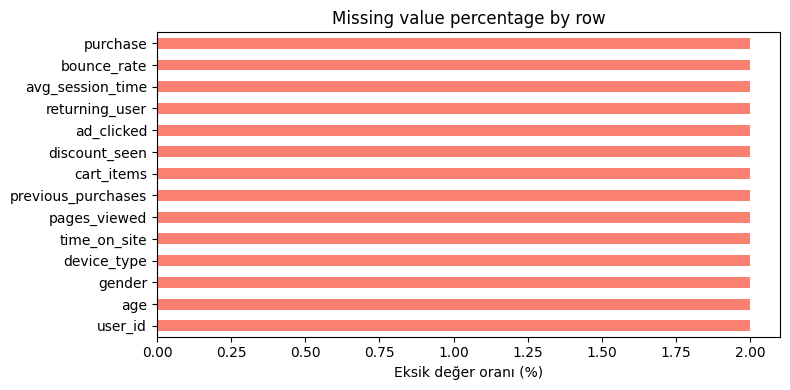

In [228]:
if not null_df.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    null_df["Missing value %"].plot(kind="barh", ax=ax, color="salmon")
    ax.set_xlabel("Eksik değer oranı (%)")
    ax.set_title("Missing value percentage by row")
    plt.tight_layout()
    plt.show()
else:
    print("No missing value")


### duplicate rows

In [229]:
dup = df.duplicated().sum()
print(f"The number of duplicated rows: {dup}")

The number of duplicated rows: 0


In [230]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Numerical variables ({len(num_cols)}): {num_cols}")
print(f"Categorical variables ({len(cat_cols)}): {cat_cols}")

Numerical variables (12): ['user_id', 'age', 'time_on_site', 'pages_viewed', 'previous_purchases', 'cart_items', 'discount_seen', 'ad_clicked', 'returning_user', 'avg_session_time', 'bounce_rate', 'purchase']
Categorical variables (2): ['gender', 'device_type']


### The distribution of target variable

In [231]:
print(df["purchase"].value_counts())

purchase
1.0    7827
0.0      13
Name: count, dtype: int64


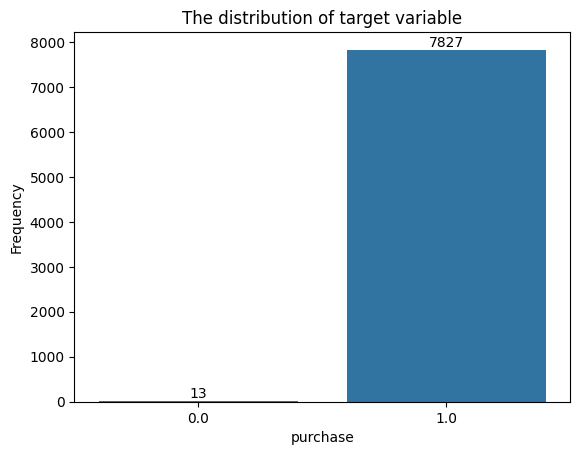

In [232]:
ax = sns.countplot(x="purchase", data=df)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("The distribution of target variable")
plt.xlabel("purchase")
plt.ylabel("Frequency")

plt.show()

### Categorical Unique Values

In [233]:
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} - ({df[col].nunique()} unique values)")

gender: 2 - (2 unique values)
device_type: 3 - (3 unique values)


In [234]:
df.dtypes

user_id               float64
age                   float64
gender                    str
device_type               str
time_on_site          float64
pages_viewed          float64
previous_purchases    float64
cart_items            float64
discount_seen         float64
ad_clicked            float64
returning_user        float64
avg_session_time      float64
bounce_rate           float64
purchase              float64
dtype: object

In [235]:
df["user_id"]

0          1.0
1          2.0
2          3.0
3          4.0
4          5.0
5          6.0
6          7.0
7          8.0
8          9.0
9         10.0
10        11.0
11        12.0
12        13.0
13        14.0
14        15.0
15        16.0
16        17.0
17        18.0
18        19.0
19        20.0
20        21.0
21        22.0
22        23.0
23        24.0
24        25.0
25        26.0
26        27.0
27        28.0
28        29.0
29        30.0
30        31.0
31        32.0
32        33.0
33        34.0
34        35.0
35        36.0
36        37.0
37        38.0
38        39.0
39        40.0
40        41.0
41        42.0
42        43.0
43        44.0
44        45.0
45        46.0
46        47.0
47        48.0
48        49.0
49        50.0
50        51.0
51        52.0
52        53.0
53        54.0
54        55.0
55        56.0
56        57.0
57        58.0
58        59.0
59        60.0
60        61.0
61        62.0
62        63.0
63        64.0
64        65.0
65        66.0
66        

In [236]:
def grab_col_names(dataframe, cat_th = 10, car_th = 20):
  cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

  num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                dataframe[col].dtypes != "O"]

  cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                dataframe[col].dtypes in ["string", "object", "category", "bool"]]
  cat_cols = cat_cols + num_but_cat
  cat_cols = [col for col in cat_cols if col not in cat_but_car]

  num_cols = [col for col in dataframe.columns if dataframe[col].dtypes in ["int","float"] and col not in cat_cols]


  print(f"Observations: {dataframe.shape[0]}")
  print(f"Variables: {dataframe.shape[1]}")
  print(f"cat_cols: {len(cat_cols)}")
  print(f"num_cols: {len(num_cols)}")
  print(f"num_but_cat: {len(num_but_cat)}")
  print(f"cat_but_car: {len(cat_but_car)}")
  return cat_cols, num_cols, cat_but_car

  cat_cols, num_cols, cat_but_car = grab_col_names(df)



In [237]:
grab_col_names(df)

Observations: 8000
Variables: 14
cat_cols: 6
num_cols: 8
num_but_cat: 6
cat_but_car: 0


(['gender',
  'device_type',
  'discount_seen',
  'ad_clicked',
  'returning_user',
  'purchase'],
 ['user_id',
  'age',
  'time_on_site',
  'pages_viewed',
  'previous_purchases',
  'cart_items',
  'avg_session_time',
  'bounce_rate'],
 [])

### Numerical columns

In [238]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median(), inplace=True)

### Categorical columns

In [239]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0], inplace=True)

### Binary Columns

In [240]:
binary_cols = ["ad_clicked", "returning_user"]

for col in binary_cols:
    df[col] = df[col].fillna(df[col].mode()[0], inplace=True)

In [241]:
df = df.drop(columns=["user_id"])

In [242]:
df.isnull().sum()

age                   0
gender                0
device_type           0
time_on_site          0
pages_viewed          0
previous_purchases    0
cart_items            0
discount_seen         0
ad_clicked            0
returning_user        0
avg_session_time      0
bounce_rate           0
purchase              0
dtype: int64

In [243]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [244]:
#Calculate thresholds
def outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    iqr = quartile3 - quartile1
    up_limit = quartile3 + iqr*1.5
    low_limit = quartile1 - iqr*1.5
    return low_limit, up_limit

In [245]:
#Are there any outliers
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

In [246]:
for col in num_cols:
    print(col, check_outlier(df, col))

age False
time_on_site False
pages_viewed False
previous_purchases False
cart_items False
discount_seen False
ad_clicked False
returning_user False
avg_session_time True
bounce_rate False
purchase True


In [247]:
df["purchase"].dtype

dtype('float64')

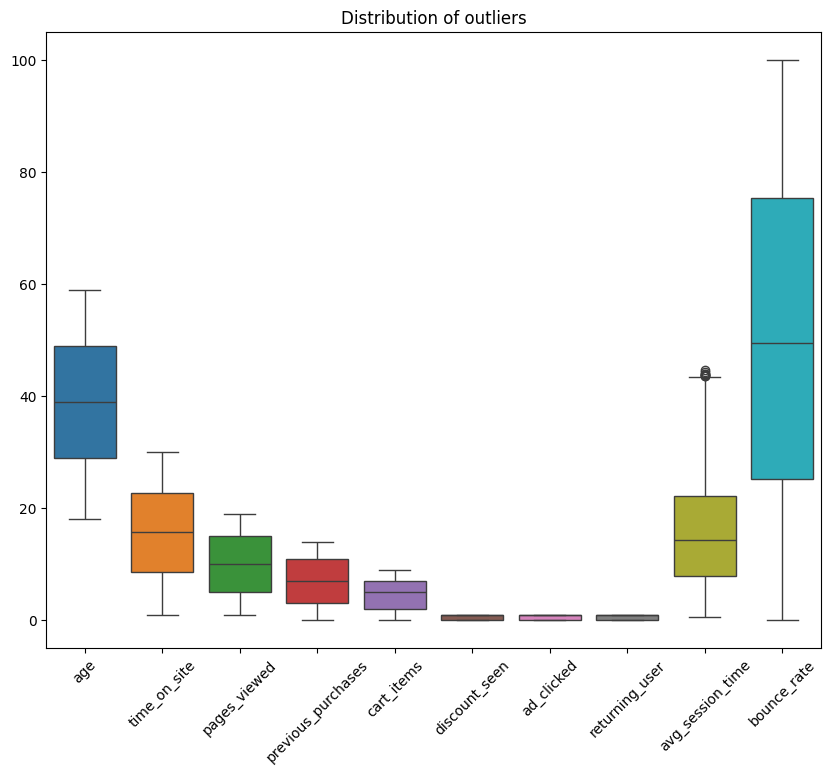

In [248]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df.drop(columns=["purchase"]))
plt.title("Distribution of outliers")
plt.xticks(rotation=45)
plt.show()

### Correlation Analysis

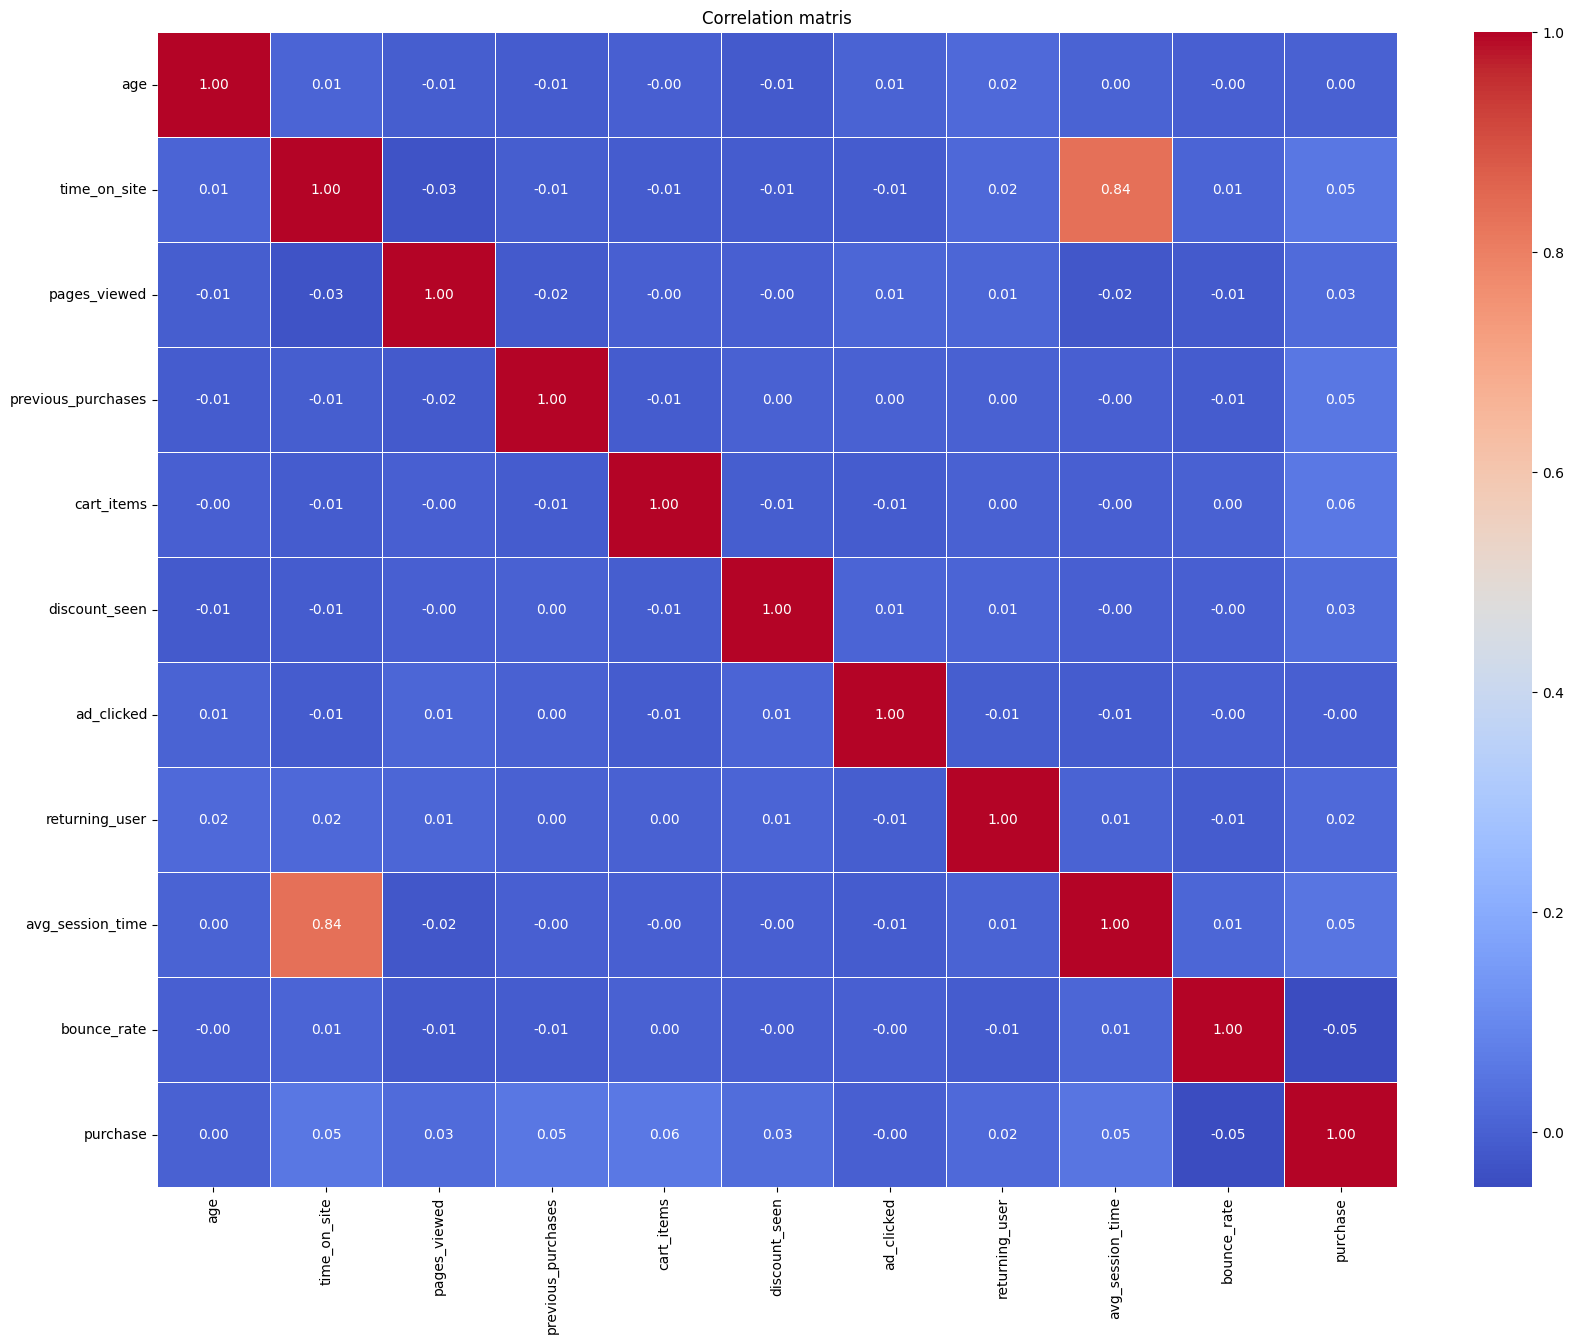

In [249]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(20,15))

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",
            fmt=".2f", linewidths=0.5)
plt.title("Correlation matris")
plt.show()

### Model preparation

In [250]:
#ENCODING
cat_cols_to_encode = ["gender", "device_type"]

le = LabelEncoder()
for col in cat_cols_to_encode:
    df[col] = le.fit_transform(df[col].astype(str))

#df = pd.get_dummies(df, columns=['gender', 'device_type'], drop_first=True)


In [251]:
#BASE MODEL BUILDING
y = df["purchase"]
X = df.drop("purchase", axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42, stratify = y)



In [252]:
#scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [253]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [254]:
#Accuracy and confusion matrix
y_pred = knn.predict(X_test)

In [255]:
score = accuracy_score(y_test, y_pred)
score

0.9983333333333333

In [256]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[   0,    4],
       [   0, 2396]])

In [258]:
class_report = classification_report(y_test, y_pred)
class_report

'              precision    recall  f1-score   support\n\n         0.0       0.00      0.00      0.00         4\n         1.0       1.00      1.00      1.00      2396\n\n    accuracy                           1.00      2400\n   macro avg       0.50      0.50      0.50      2400\nweighted avg       1.00      1.00      1.00      2400\n'